# Урок 6.3. Многоклассовая классификация: softmax и K деревьев

**Интерактивная версия:** `lessons/lesson_6_3/web/index.html`

1. Softmax-бустинг с нуля: одна итерация по шагам.
2. Сверка с gbcourse и scikit-learn.
3. Один против всех.
4. Настоящие данные: цифры (10 классов).

In [1]:
import sys
import time
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_digits
from gbcourse import datasets, GBClassifier, RegressionTree
from gbcourse._numeric import softmax
from gbcourse.plotting import use_course_style, plot_decision_surface

use_course_style()

## 1. Одна итерация вручную

In [2]:
X, y = datasets.classification_2d(kind="blobs3", n=300, noise=0.7, seed=65)
K = 3
Y = np.eye(K)[y]
prior = Y.mean(0)
F = np.tile(np.log(prior) - np.log(prior).mean(), (len(y), 1))
P = softmax(F)
R = Y - P                                         # K наборов псевдо-остатков
nu = 0.2
for k in range(K):
    tree = RegressionTree(max_depth=2).fit(X, -R[:, k])
    for leaf in tree.leaves:                     # шаг Фридмана с множителем (K−1)/K
        r = R[leaf.rows, k]
        leaf.value = (K - 1) / K * r.sum() / np.sum(np.abs(r) * (1 - np.abs(r)))
    tree.refresh_values()
    F[:, k] += nu * tree.predict(X)
ours = GBClassifier(n_estimators=1, learning_rate=nu, max_depth=2).fit(X, y)
print("ручная итерация − gbcourse:", np.abs(F - ours.predict_raw(X)).max())

ручная итерация − gbcourse: 9.159339953157541e-16


## 2. Полная модель и сверка

расхождение вероятностей: 2.220446049250313e-16


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


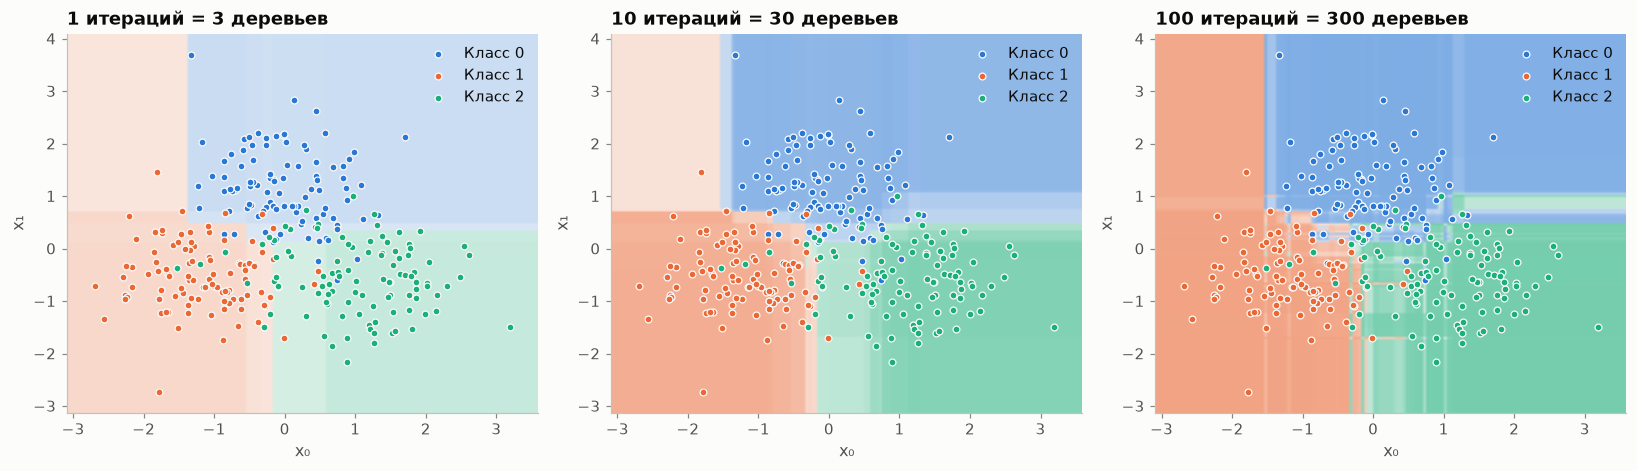

In [3]:
m = GBClassifier(n_estimators=100, learning_rate=0.2, max_depth=2).fit(X, y)
sk = GradientBoostingClassifier(n_estimators=100, learning_rate=0.2, max_depth=2).fit(X, y)
print("расхождение вероятностей:", np.abs(m.predict_proba(X) - sk.predict_proba(X)).max())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, it in zip(axes, (1, 10, 100)):
    plot_decision_surface(ax, lambda Z, it=it: m.predict_proba(Z, n_iter=it), X, y, title=f"{it} итераций = {3 * it} деревьев")
plt.tight_layout()
plt.show()

## 3. Один против всех

In [4]:
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X, y, test_size=0.3, seed=0)
ovr = [GBClassifier(n_estimators=100, learning_rate=0.2, max_depth=2).fit(X_tr, (y_tr == k).astype(int)) for k in range(K)]
p_ovr = np.column_stack([c.predict_proba(X_te)[:, 1] for c in ovr])
print("сумма вероятностей OvR без нормировки (первые 3):", p_ovr[:3].sum(1).round(3))
p_ovr /= p_ovr.sum(1, keepdims=True)
p_sm = GBClassifier(n_estimators=100, learning_rate=0.2, max_depth=2).fit(X_tr, y_tr).predict_proba(X_te)
for name, P_ in (("softmax", p_sm), ("один против всех", p_ovr)):
    print(f"{name:17s}: точность {np.mean(P_.argmax(1) == y_te):.3f}, log-loss {-np.mean(np.log(P_[np.arange(len(y_te)), y_te])):.4f}")

сумма вероятностей OvR без нормировки (первые 3): [1.005 1.361 1.002]
softmax          : точность 0.856, log-loss 0.4618
один против всех : точность 0.856, log-loss 0.4917


## 4. Цифры: 10 классов, 64 признака (scikit-learn)

In [5]:
Xd, yd = load_digits(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = datasets.train_test_split(Xd, yd, test_size=0.3, seed=0)
t0 = time.perf_counter()
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3).fit(Xd_tr, yd_tr)
print(f"точность на тесте {clf.score(Xd_te, yd_te):.3f}; обучение {time.perf_counter() - t0:.1f} с; деревьев {clf.estimators_.size}")

точность на тесте 0.959; обучение 4.1 с; деревьев 1000


## Упражнения

1. Докажите, что при K = 2 softmax-бустинг эквивалентен логистическому (с точностью до масштаба логитов).
2. Сколько времени занимает обучение на цифрах при K = 10 против бинарной задачи «0 против остальных»?

Решения: `python lessons/lesson_6_3/exercises/solutions.py`.